<a href="https://colab.research.google.com/github/Ayushman125/Essentials_of_AI/blob/main/EAI_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment2

1. Analyze the behaviour and relationship among MOCT for:

    a.Unimodel symmetric distribution.(mean = mode = median)

    b.Right Skewed distribution.(mode < median < mean)

    c.Left Skewed distribution. (mode > median > mean)

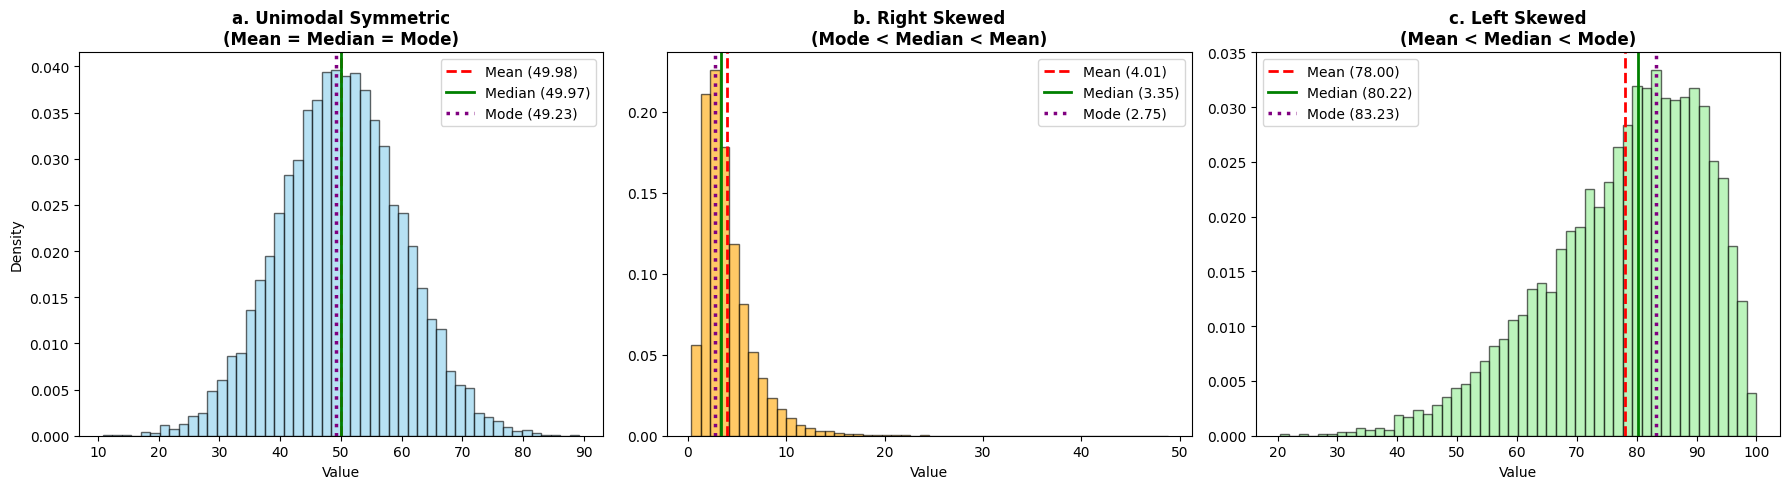

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set seed for reproducibility
np.random.seed(42)
n_samples = 10000

# 1. Generate Datasets
data_sym = np.random.normal(loc=50, scale=10, size=n_samples)            # Symmetric
data_right = np.random.lognormal(mean=1.2, sigma=0.6, size=n_samples)    # Right-Skewed
data_left = stats.beta.rvs(a=7, b=2, size=n_samples) * 100               # Left-Skewed

def get_mode(data, num_bins=50):
    counts, bin_edges = np.histogram(data, bins=num_bins)
    max_idx = np.argmax(counts)
    return (bin_edges[max_idx] + bin_edges[max_idx+1]) / 2

# Plotting Setup
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (data_sym, 'a. Unimodal Symmetric\n(Mean = Median = Mode)', 'skyblue', axes[0]),
    (data_right, 'b. Right Skewed\n(Mode < Median < Mean)', 'orange', axes[1]),
    (data_left, 'c. Left Skewed\n(Mean < Median < Mode)', 'lightgreen', axes[2])
]

for data, title, color, ax in configs:
    mean_val = np.mean(data)
    median_val = np.median(data)
    mode_val = get_mode(data)

    ax.hist(data, bins=50, density=True, alpha=0.6, color=color, edgecolor='black')
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.2f})')
    ax.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median ({median_val:.2f})')
    ax.axvline(mode_val, color='purple', linestyle=':', linewidth=2.5, label=f'Mode ({mode_val:.2f})')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend()

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()

2.Analyze the impact of various transformations (Shifting, Scaling and Mixed Operations) on MOCT.

In [ ]:
# Generate baseline dataset
X = np.random.lognormal(mean=1.5, sigma=0.5, size=100000)

# Transformation parameters
a = 2.5  # Scale factor
c = 15.0 # Shift constant

# Define helper to compute MOCT
def get_moct(arr):
    mean_val = np.mean(arr)
    median_val = np.median(arr)
    mode_val = stats.mode(arr, keepdims=True).mode[0]
    return mean_val, median_val, mode_val

# Transformations
X_shift = X + c
X_scale = a * X
X_mixed = a * X + c

# Calculate MOCTs
orig_mean, orig_med, orig_mode = get_moct(X)
s_mean, s_med, s_mode = get_moct(X_shift)
sc_mean, sc_med, sc_mode = get_moct(X_scale)
m_mean, m_med, m_mode = get_moct(X_mixed)

print(f"Original MOCT   : Mean={orig_mean:.1f}, Median={orig_med:.1f}, Mode={orig_mode:.1f}")
print(f"Shifted (+{c})   : Mean={s_mean:.1f}, Median={s_med:.1f}, Mode={s_mode:.1f}")
print(f"Scaled (*{a})    : Mean={sc_mean:.1f}, Median={sc_med:.1f}, Mode={sc_mode:.1f}")
print(f"Mixed (*{a}+{c}) : Mean={m_mean:.1f}, Median={m_med:.1f}, Mode={m_mode:.1f}")

Original MOCT   : Mean=5.1, Median=4.5, Mode=0.5
Shifted (+15.0)   : Mean=20.1, Median=19.5, Mode=15.5
Scaled (*2.5)    : Mean=12.7, Median=11.2, Mode=1.2
Mixed (*2.5+15.0) : Mean=27.7, Median=26.2, Mode=16.2


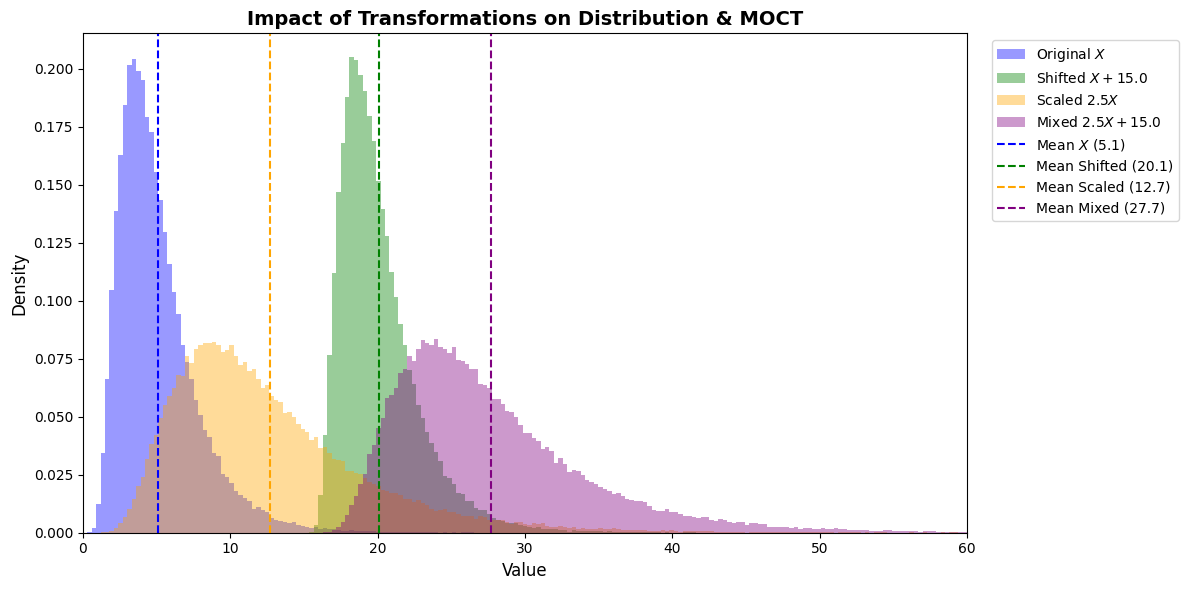

In [ ]:
# Calculate empirical mode via histogram density peak (better for continuous data visualization)
def get_empirical_mode(arr, num_bins=100):
    counts, bin_edges = np.histogram(arr, bins=num_bins)
    max_idx = np.argmax(counts)
    return (bin_edges[max_idx] + bin_edges[max_idx+1]) / 2

# Plot comparison on a single plot (Original vs Shifted vs Scaled vs Mixed)
fig, ax = plt.subplots(figsize=(12, 6))

bins = np.linspace(0, 60, 200)

ax.hist(X, bins=bins, density=True, alpha=0.4, label='Original $X$', color='blue', edgecolor='none')
ax.hist(X_shift, bins=bins, density=True, alpha=0.4, label=f'Shifted $X + {c}$', color='green', edgecolor='none')
ax.hist(X_scale, bins=bins, density=True, alpha=0.4, label=f'Scaled ${a}X$', color='orange', edgecolor='none')
ax.hist(X_mixed, bins=bins, density=True, alpha=0.4, label=f'Mixed ${a}X + {c}$', color='purple', edgecolor='none')

# Add mean lines for each
datasets = [
    (X, 'blue', '$X$'),
    (X_shift, 'green', 'Shifted'),
    (X_scale, 'orange', 'Scaled'),
    (X_mixed, 'purple', 'Mixed')
]

for data, col, lbl in datasets:
    mn = np.mean(data)
    md = np.median(data)
    mo = get_empirical_mode(data)
    ax.axvline(mn, color=col, linestyle='--', linewidth=1.5, label=f'Mean {lbl} ({mn:.1f})')

ax.set_title('Impact of Transformations on Distribution & MOCT', fontsize=14, fontweight='bold')
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(0, 60)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('moct_transformations_comparison.png', dpi=300)
plt.show()